### 1. Scraping

In [6]:
%pip install scrapy crochet
import crochet
import scrapy
from scrapy.crawler import CrawlerRunner

# Initialize crochet (prevents ReactorNotRestartable errors)
crochet.setup()


class BooksSpider(scrapy.Spider):
    name = "books"
    allowed_domains = ["books.toscrape.com"]
    start_urls = ["https://books.toscrape.com/"]

    def parse(self, response):
        book_links = response.css(
            "article.product_pod h3 a::attr(href)"
        ).getall()
        for link in book_links:
            yield response.follow(link, callback=self.parse_book)

        next_page = response.css("li.next a::attr(href)").get()
        if next_page:
            yield response.follow(next_page, callback=self.parse)

    def parse_book(self, response):
        title = response.css("div.product_main h1::text").get()
        if title:
            title = title.strip()

        category = response.css("ul.breadcrumb li:nth-child(3) a::text").get()
        if category:
            category = category.strip()

        price = response.css("p.price_color::text").get()

        rating_classes = response.css("p.star-rating::attr(class)").get()
        rating = None
        if rating_classes:
            rating = rating_classes.replace("star-rating", "").strip()

        table_rows = response.css("table.table-striped tr")
        details = {}
        for row in table_rows:
            key = row.css("th::text").get()
            val = row.css("td::text").get()
            if key and val:
                details[key.strip()] = val.strip()

        availability = details.get("Availability")
        description = response.css("div#product_description + p::text").get()
        if description:
            description = description.strip()

        upc = details.get("UPC")
        number_of_reviews = details.get("Number of reviews")
        product_url = response.url

        yield {
            "title": title,
            "category": category,
            "price": price,
            "rating": rating,
            "availability": availability,
            "product_description": description,
            "UPC": upc,
            "number_of_reviews": number_of_reviews,
            "product_url": product_url,
        }


# Configure CrawlerRunner with the matching EPollReactor setting
runner = CrawlerRunner(
    settings={
        "TWISTED_REACTOR": "twisted.internet.epollreactor.EPollReactor",  # Fixes reactor mismatch
        "FEEDS": {
            "raw_books.csv": {"format": "csv", "encoding": "utf8", "overwrite": True},
        },
        "USER_AGENT": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
        "ROBOTSTXT_OBEY": True,
        "LOG_LEVEL": "INFO",
    }
)


@crochet.wait_for(timeout=120.0)
def run_spider():
    return runner.crawl(BooksSpider)


# Run spider
run_spider()

### 2.Data Preprocessing

In [10]:
import re
import pandas as pd

# ==========================================================
# Read the Raw Dataset from Task 1 Scrapy Output
# ==========================================================

df = pd.read_csv("raw_books.csv")

# ==========================================================
# Map Scrapy Field Names to Notebook Column Schema
# ==========================================================

column_mapping = {
    "title": "Title",
    "category": "Category",
    "price": "Price",
    "rating": "Rating",
    "availability": "Availability",
    "product_description": "Product Description",
    "UPC": "UPC",
    "number_of_reviews": "Number of Reviews",
    "product_url": "Product URL",
}

# Rename columns if loaded from Scrapy's snake_case output
df.rename(columns=column_mapping, inplace=True)

# ==========================================================
# Remove Extra Spaces
# ==========================================================

text_columns = [
    "Title",
    "Category",
    "Product Description",
    "UPC",
    "Product URL",
]

for column in text_columns:
    if column in df.columns:
        df[column] = df[column].astype(str).str.strip()

# ==========================================================
# Handle Missing Product Descriptions
# ==========================================================

df["Product Description"] = df["Product Description"].replace("nan", pd.NA)
df["Product Description"] = df["Product Description"].fillna(
    "No Description Available"
)

# ==========================================================
# Remove Duplicate Books using UPC
# ==========================================================

df = df.drop_duplicates(subset="UPC")

# ==========================================================
# Convert Price to Numeric
# Handles:
# £51.77
# Â£51.77
# ==========================================================

df["Price"] = df["Price"].astype(str).str.extract(r"(\d+\.\d+)")[0]

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# ==========================================================
# Convert Rating into Integers
# ==========================================================

rating_map = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}

df["Rating"] = df["Rating"].map(rating_map)

# ==========================================================
# Extract Stock Count
# Example:
# In stock (22 available) --> 22
# ==========================================================


def extract_stock(text):
    match = re.search(r"(\d+)", str(text))
    if match:
        return int(match.group())
    return 0


df["Stock Count"] = df["Availability"].apply(extract_stock)

# ==========================================================
# Remove Availability Column
# ==========================================================

if "Availability" in df.columns:
    df.drop(columns=["Availability"], inplace=True)

# ==========================================================
# Feature 1
# Description Word Count
# ==========================================================

df["Description Word Count"] = df["Product Description"].apply(
    lambda x: len(str(x).split())
)

# ==========================================================
# Feature 2
# Price Band
# ==========================================================


def price_band(price):

    if pd.isna(price):
        return "Unknown"

    elif price < 20:
        return "Low"

    elif price < 40:
        return "Medium"

    else:
        return "High"


df["Price Band"] = df["Price"].apply(price_band)

# ==========================================================
# Feature 3
# Affordability Score
# Higher Score = More Affordable
# ==========================================================

max_price = df["Price"].max()

df["Affordability Score"] = (
    ((max_price - df["Price"]) / max_price) * 100
).round(2)

# ==========================================================
# Feature 4
# Recommended Book
# ==========================================================

df["Recommended"] = (
    (df["Rating"] >= 4) & (df["Price"] < 40)
).map({True: "Yes", False: "No"})

# ==========================================================
# Save Clean Dataset as CSV
# ==========================================================

df.to_csv("books_cleaned.csv", index=False, encoding="utf-8")

# ==========================================================
# Save Clean Dataset as JSON
# ==========================================================

df.to_json("books_cleaned.json", orient="records", indent=4)

# ==========================================================
# Display Summary
# ==========================================================

print("\n========== PREPROCESSING SUMMARY ==========")

print(f"Total Records : {len(df)}")
print(f"Total Columns : {len(df.columns)}")

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate UPC Values:")
print(df["UPC"].duplicated().sum())

print("\nFiles Generated Successfully")
print("✔ books_cleaned.csv")
print("✔ books_cleaned.json")

print("\nFirst 5 Records:")
print(df.head())


========== PREPROCESSING SUMMARY ==========
Total Records : 1000
Total Columns : 13

Column Names:
['Title', 'Category', 'Price', 'Rating', 'Product Description', 'UPC', 'Number of Reviews', 'Product URL', 'Stock Count', 'Description Word Count', 'Price Band', 'Affordability Score', 'Recommended']

Missing Values:
Title                     0
Category                  0
Price                     0
Rating                    0
Product Description       0
UPC                       0
Number of Reviews         0
Product URL               0
Stock Count               0
Description Word Count    0
Price Band                0
Affordability Score       0
Recommended               0
dtype: int64

Duplicate UPC Values:
0

Files Generated Successfully
✔ books_cleaned.csv
✔ books_cleaned.json

First 5 Records:
                                               Title     Category  Price  \
0     Starving Hearts (Triangular Trade Trilogy, #1)      Default  13.99   
1                                       

### 3. Visualization

Summary Statistics
            Price       Rating  Number of Reviews  Stock Count  \
count  1000.00000  1000.000000             1000.0  1000.000000   
mean     35.07035     2.923000                0.0     8.585000   
std      14.44669     1.434967                0.0     5.654622   
min      10.00000     1.000000                0.0     1.000000   
25%      22.10750     2.000000                0.0     3.000000   
50%      35.98000     3.000000                0.0     7.000000   
75%      47.45750     4.000000                0.0    14.000000   
max      59.99000     5.000000                0.0    22.000000   

       Description Word Count  Affordability Score  
count             1000.000000          1000.000000  
mean               236.381000            41.539680  
std                107.551267            24.081916  
min                  3.000000             0.000000  
25%                177.000000            20.890000  
50%                222.500000            40.025000  
75%            

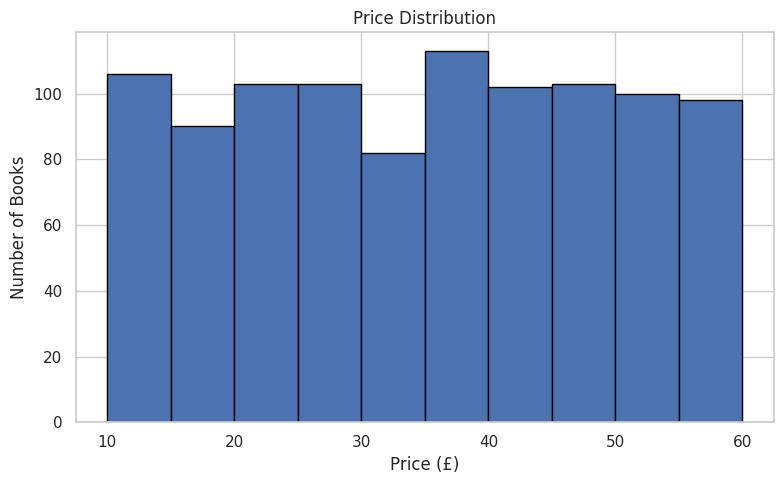

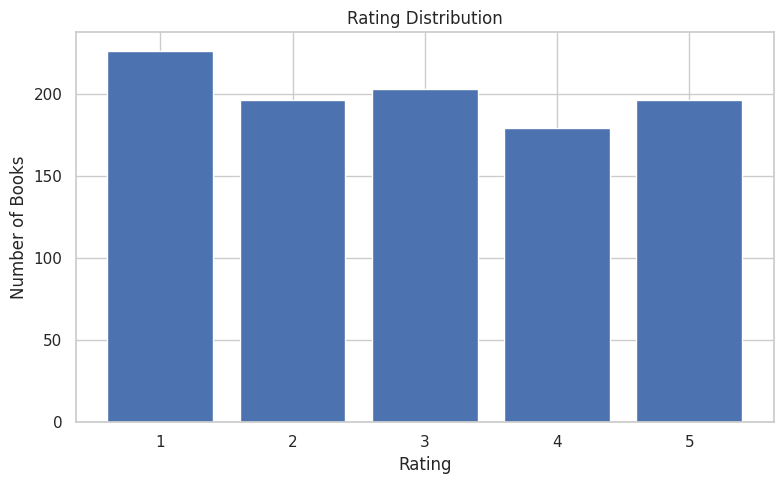

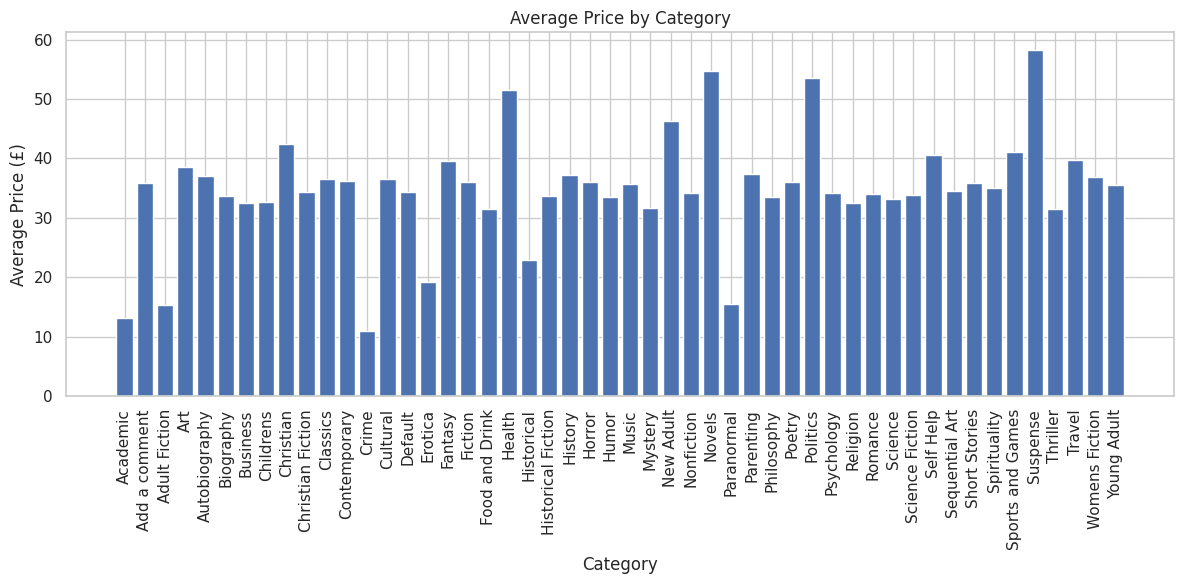

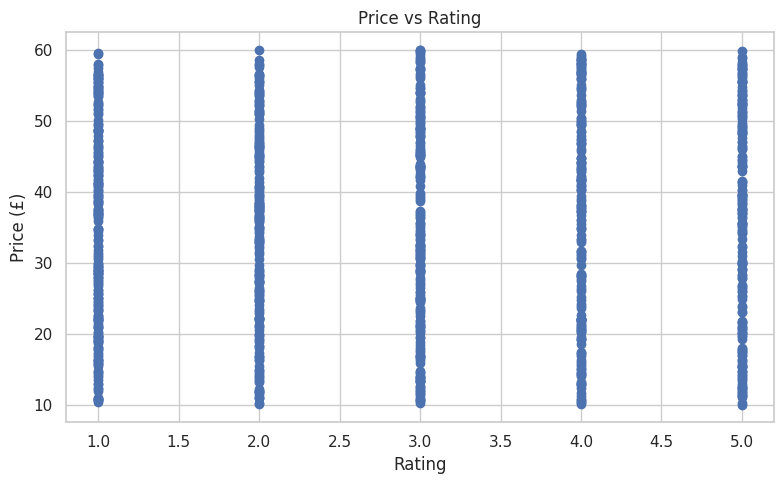

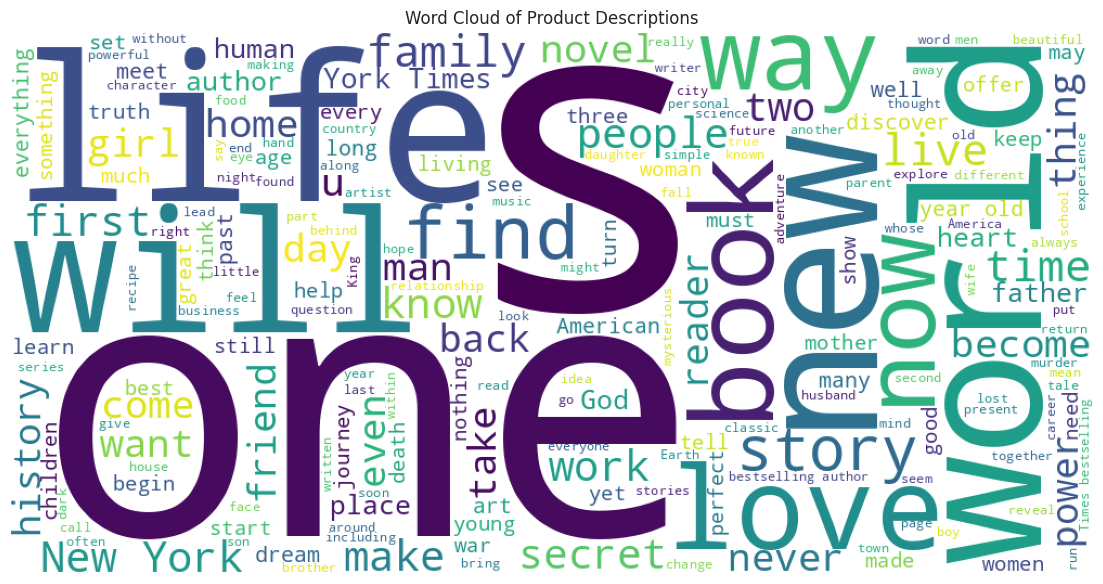


Category Patterns
Category
Default               152
Nonfiction            110
Sequential Art         75
Add a comment          67
Fiction                65
Young Adult            54
Fantasy                48
Romance                35
Mystery                32
Food and Drink         30
Childrens              29
Historical Fiction     26
Poetry                 19
Classics               19
History                18
Horror                 17
Womens Fiction         17
Science Fiction        16
Science                14
Music                  13
Business               12
Travel                 11
Philosophy             11
Thriller               11
Humor                  10
Autobiography           9
Art                     8
Religion                7
Psychology              7
Spirituality            6
New Adult               6
Christian Fiction       6
Sports and Games        5
Self Help               5
Biography               5
Health                  4
Politics                3
Contempora

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Read cleaned dataset
df = pd.read_csv("books_cleaned.csv")

# =====================================================
# Summary Statistics
# =====================================================

print("Summary Statistics")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

# =====================================================
# Plot 1 - Price Distribution
# =====================================================

plt.figure(figsize=(8,5))
plt.hist(df["Price"], bins=10, edgecolor="black")
plt.title("Price Distribution")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.savefig("price_distribution.png")
plt.show()

# =====================================================
# Plot 2 - Rating Distribution
# =====================================================

rating_counts = df["Rating"].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(rating_counts.index.astype(str), rating_counts.values)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.savefig("rating_distribution.png")
plt.show()

# =====================================================
# Plot 3 - Average Price by Category
# =====================================================

avg_price = df.groupby("Category")["Price"].mean()

plt.figure(figsize=(12,6))
plt.bar(avg_price.index, avg_price.values)
plt.xticks(rotation=90)
plt.title("Average Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Price (£)")
plt.tight_layout()
plt.savefig("average_price_by_category.png")
plt.show()

# =====================================================
# Plot 4 - Price vs Rating
# =====================================================

plt.figure(figsize=(8,5))
plt.scatter(df["Rating"], df["Price"])
plt.title("Price vs Rating")
plt.xlabel("Rating")
plt.ylabel("Price (£)")
plt.tight_layout()
plt.savefig("price_vs_rating.png")
plt.show()

# =====================================================
# Plot 5 - Word Cloud
# =====================================================

text = " ".join(df["Product Description"].astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of Product Descriptions")
plt.tight_layout()
plt.savefig("wordcloud.png")
plt.show()

# =====================================================
# Required Analysis
# =====================================================

print("\nCategory Patterns")
print(df["Category"].value_counts())

print("\nHighly Rated Books")
print(df[df["Rating"] == 5][["Title", "Category", "Rating"]])

print("\nStock Patterns")
print(df.groupby("Category")["Stock Count"].mean())

print("\nMissing Values")
print(df.isnull().sum())

### 4. Interpretation

From the price distribution graph, it is clear that most of the books are priced in the middle range, while only a few books are available at very low or very high prices. This shows probably that the books on the website are generally priced within a similar range.
From the price vs rating scatter plot, it shows that some low rated books also have more than average price. Likewise, some reasonable price books also have high ratings.
The stock count is different for different categories, which means some categories have more books available than others.
According to the dataset of 100 books Historical Fiction category has the highest price among all.
Based on the analysis, books with higher ratings and comparatively lower prices provide the best value for readers. These books offer a good balance between affordability and quality, making them a better choice for customers looking for value for money.
